# Mini Project 2
Nama: Faraday Barr Fatahillah

Dataset: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

Dataset NEW: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

#### Background

Diabetes merupakan penyakit kronis yang terjadi saat pankreas tidak dapat membuat hormon Insulin. Jika dibiarkan, penyakit ini dapat menyebabkan buta, gagal ginjal, struk, dan lain lagi. Menurut World Health Organization (WHO), [mulai tahun 1990 hingga 2022 masyarakat yang memiliki diabetes naik hingga 630 juta orang](https://www.who.int/news-room/fact-sheets/detail/diabetes). Peningkatan ini menunjukkan bahwa diabetes merupakan tantangan kesehatan masyarakat yang sangat penting, sehingga diperlukan pendekatan berbasis data untuk membantu deteksi dini dan pengambilan keputusan medis. Oleh karena itu, pemanfaatan machine learning menjadi pendekatan yang berpotensi untuk membantu deteksi dini diabetes.

#### Problem Statements

1. Bisakah model machine learning mendeteksi seseorang memiliki diabetes berdasarkan data kesehatan?
2. Model machine learning mana yang dapat melakukan deteksi diabetes paling baik, dan bagaimana untuk di optimasi lebih lanjut?

#### Objective

Membuat dan membandingkan minimal dua model machine learning untuk mendeteksi diabetes

#### Import Library

In [1]:
# All library needed

# Base ML Library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Scaler
from sklearn.preprocessing import StandardScaler

# Dataset Splitter
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Metrics and Reports
from sklearn.metrics import classification_report, recall_score



#### Load Dataset

In [2]:
# Load dataset
df = pd.read_csv('diabetes_bfrss.csv')
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
# Cek informasi Dataset dari segi jumlah data, fitur, null-value, dan jenis data 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [4]:
# Cek data unik setiap tabel walaupun data merupakan bentuk float semua
rows = []

for col in df.columns:
    rows.append({
        "Column": col,
        "Unique Values": df[col].unique() # Gunakan looping dan method unique() untuk cek semua data di masukkan ke dalam list 
    })

unique_table = pd.DataFrame(rows) # Ubah list ke dataframe biar mudah untuk dilihat
unique_table


,Column,Unique Values
0,Diabetes_012,"[0.0, 2.0, 1.0]"
1,HighBP,"[1.0, 0.0]"
2,HighChol,"[1.0, 0.0]"
3,CholCheck,"[1.0, 0.0]"
4,BMI,"[40.0, 25.0, 28.0, 27.0, 24.0, 30.0, 34.0, 26...."
5,Smoker,"[1.0, 0.0]"
6,Stroke,"[0.0, 1.0]"
7,HeartDiseaseorAttack,"[0.0, 1.0]"
8,PhysActivity,"[0.0, 1.0]"
9,Fruits,"[0.0, 1.0]"


Melihat hasil data unik per fitur, dataset ini lebih banyak memiliki kolom kategorikal dari pada kolom numerikal. Hal ini perlu di sesuaikan dengan deskripsi dataset yang sudah diberikan. Berikut merupakan informasi yang didapatkan.

Label per Column:
1. 'Diabates_012': Target, 0 = no diabetes, 1 = prediabetes, 2 = diabetes
2. 'HighBP': Binary, 0 = no high, BP 1 = high BP
3. 'HighChol': Binary, 0 = no high cholesterol, 1 = high cholesterol
4. 'CholCheck': Binary, 0 = no cholesterol check in 5 years, 1 = yes cholesterol check in 5 years
5. 'BMI': Float
6. 'Smoker': Binary, 0 = no, 1 = yes
7. 'Stroke': Binary, 0 = no, 1 = yes
8. 'HeartDiseaseorAttack, Binary 0 = no, 1 = yes
9. 'PhysActivity': Binary, 0 = no, 1 = yes
10. 'Fruits': Binary, 0 = no, 1 = yes
11. 'Veggies': Binary, 0 = no, 1 = yes
12. 'HvyAlcoholConsump': Binary, 0 = no, 1 = yes
13. 'AnyHealthCare': Binary, 0 = no, 1 = yes
14. 'NoDocbcCost': Binary, 0 = no, 1 = yes
15. 'GenHlth': Categorical, 1 = excellent, 2 = very good, 3 = good, 4 = fair, 5 = poor
16. 'MentHlth': Float, scale 1-30 days
17. 'PhysHlth': Float, scale 1-30 days
18. 'DiffWalk': Binary, 0 = no, 1 = yes
19. 'Sex': Binary, 0 = female, 1 = male
20. 'Age': Categorical, 1 = 18-24, 9 = 60-64, 13 = 80 or older
21. 'Education': Categorical, 1 = Never attended school or only kindergarten, 2 = Grades 1 through 8 (Elementary), 3 = Grades 9 through 11 (Some high school), 4 = Grade 12 or GED (High school graduate), 5 = College 1 year to 3 years (Some college or technical school), 6 = College 4 years or more (College graduate)
22. 'Income': Categorical, 1 = less than $10,000, 5 = less than $35,000, 8 = $75,000 or more


Dari deskripsi ini, data yang dapat dihitung sebagai kolom numerik yaitu BMI. Ada yang mungkin sedikit aneh di kolom ```MentHlth``` dan ```PhysHlth``` yang merupakan skala numerik, tetapi kelihatan cenderung lebih kategorik. Mungkin data ini akan dihilangkan atau dilakukan feature engineering.

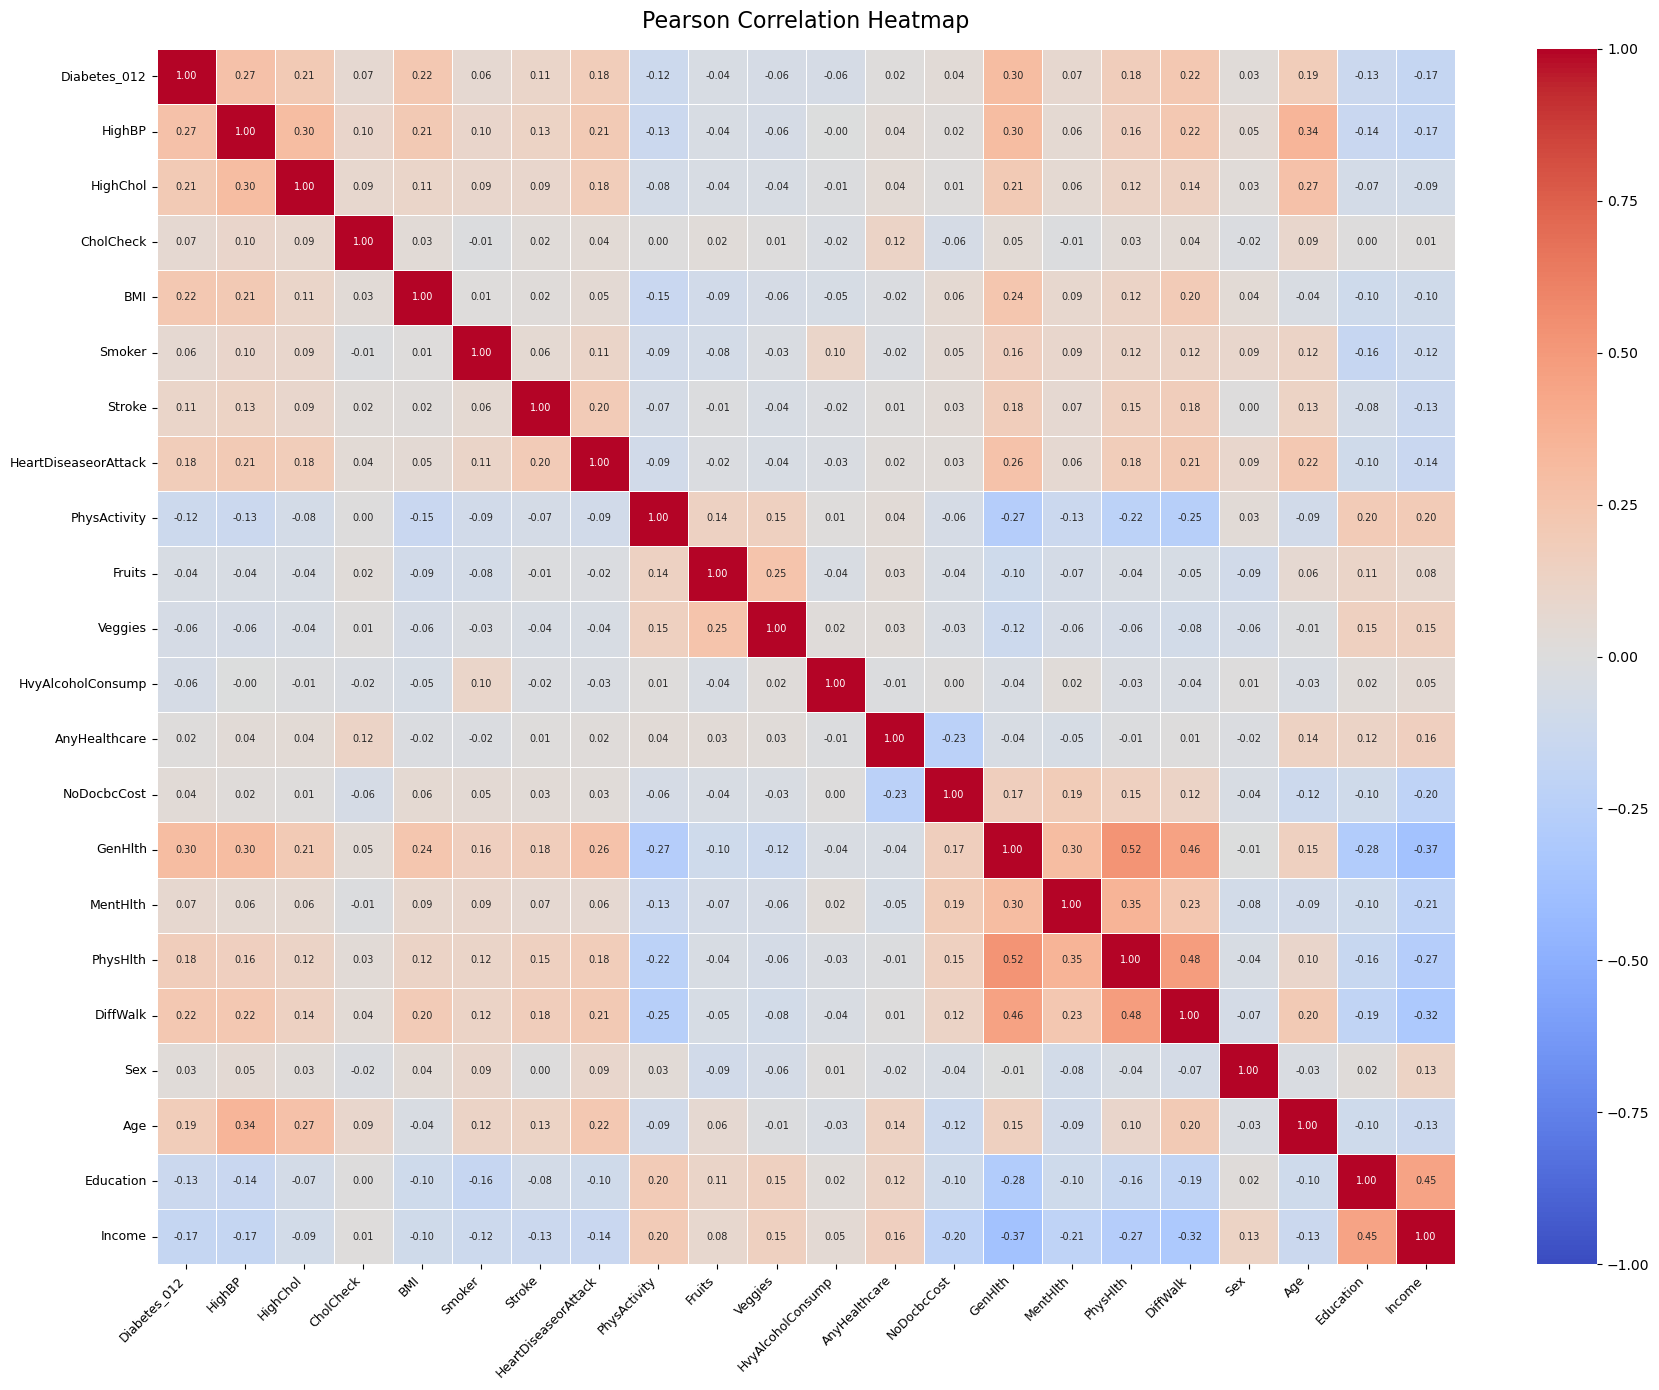

In [5]:
# Cek korelasi fitur dataset 
plt.figure(figsize=(18, 14))

cm = df.corr()

sns.heatmap(
    data=cm,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 7}
)

plt.title('Pearson Correlation Heatmap', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Melihat hasil dari confusion matrix di atas, tidak terlalu banyak yang memiliki korelasi paling signifikan dengan target (```Diabetes_012```). Fitur yang memiliki korelasi positif adalah fitur ```HighBP```, ```HighChol```, ```BMI```, ```HeartDiseasorAttack```, ```GenHlth```, ```PhysHlth```, ```DiffWalk```, dan ```Age```.

Maka dari itu, sebagian besar dari dataset kemungkinan besar akan di lakukan feature engineering baik membuat kolom baru dari campuran fitur atau mereduksi beberapa fitur. Sebelum itu, langkah selanjutnya adalah untuk distribusi data antara yang memiliki diabetes dengan yang tidak.

In [6]:
# Cek jumlah kategori dari 
df.query('Diabetes_012 == 0').count()

Diabetes_012            213703
HighBP                  213703
HighChol                213703
CholCheck               213703
BMI                     213703
Smoker                  213703
Stroke                  213703
HeartDiseaseorAttack    213703
PhysActivity            213703
Fruits                  213703
Veggies                 213703
HvyAlcoholConsump       213703
AnyHealthcare           213703
NoDocbcCost             213703
GenHlth                 213703
MentHlth                213703
PhysHlth                213703
DiffWalk                213703
Sex                     213703
Age                     213703
Education               213703
Income                  213703
dtype: int64

In [7]:
df.query('Diabetes_012 == 1').count()

Diabetes_012            4631
HighBP                  4631
HighChol                4631
CholCheck               4631
BMI                     4631
Smoker                  4631
Stroke                  4631
HeartDiseaseorAttack    4631
PhysActivity            4631
Fruits                  4631
Veggies                 4631
HvyAlcoholConsump       4631
AnyHealthcare           4631
NoDocbcCost             4631
GenHlth                 4631
MentHlth                4631
PhysHlth                4631
DiffWalk                4631
Sex                     4631
Age                     4631
Education               4631
Income                  4631
dtype: int64

In [8]:
df.query('Diabetes_012 == 2').count()

Diabetes_012            35346
HighBP                  35346
HighChol                35346
CholCheck               35346
BMI                     35346
Smoker                  35346
Stroke                  35346
HeartDiseaseorAttack    35346
PhysActivity            35346
Fruits                  35346
Veggies                 35346
HvyAlcoholConsump       35346
AnyHealthcare           35346
NoDocbcCost             35346
GenHlth                 35346
MentHlth                35346
PhysHlth                35346
DiffWalk                35346
Sex                     35346
Age                     35346
Education               35346
Income                  35346
dtype: int64

Hasil dari dataset ini menentukan bahwa:
1. Non Diabetik: 213703
2. Pre Diabetik: 4631
3. Diabetik: 35346

Melihat hasil distribusi data per kategori, data ini SANGAT imbalance. Maka dari itu perlu melakukan SMOTE untuk membuat data lebih balance. 

Hasil informasi ini menentukan terdapat beberapa hal yang dapat dilakukan, yaitu
1. Melihat hasil model dengan raw dataset,
2. Melihat hasil model dengan data yang sudah dilakukan feature engineering,
3. Melihat hasil model dengan data yang sudah dilakukan SMOTE.

#### Clean Dataset

In [9]:
# Cek null-value (walaupun semuanya tidak ada null-value)
df.isna().sum().sort_values(ascending=False)

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [10]:
# Seperti pada hasil informasi sebelumnya, ubah semua data float menjadi int (sebenarnya tidak terlalu di perlukan)
df = df.astype('int64')

In [11]:
# Cek hasilnya lagi
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_012          253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-null  int64


### Data Preprocessing

Model yang dibuat adalah untuk mendeteksi apakah model dapat mendeteksi antara orang yang diabetes dengan yang tidak diabetes, maka dari itu kategori prediabetik dapat dihilangkan.

In [12]:
# Hapus data yang memiliki kategori 1, yaitu prediabetik sesuai dengan label yang sudah dijelaskan
df = df[df['Diabetes_012'] != 1]

# Cek apakah sudah hilang atau belum
df.query('Diabetes_012 == 1').count()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [13]:
# Ubah label diabetik menjadi 1
df['Diabetes_012'] = df['Diabetes_012'].replace(2, 1)

In [14]:
# Cek unik target
df['Diabetes_012'].unique()

array([0, 1])

### Statistik Deskriptif

Bagian ini mungkin agak tricky karena sudah dijelaskan sebelumnya yang merupakan numerik asli hanya ```BMI```, dan ```BMI``` semua orang itu variatif sehingga sedikit susah untuk mencari outliernya. Tidak hanya itu, ```MtnHlth``` dan ```PhysHlth``` prediksinya akan memiliki outlier yang sangat banyak juga. Walaupun begitu akan dilakukan statistika deskriptif.

In [15]:
# Panggil semua fitur yang merupakan numerik dan hitung statistika deskriptifnya
numerik = ['BMI', 'MentHlth', 'PhysHlth']

for col in numerik:
    print(f'Mean {col}: {df[col].mean()}')
    print(f'Median {col}: {df[col].median()}')
    print(f'Mode {col}: {df[col].mode()[0]}')
    print(f'Std {col}: {df[col].std()}')
    print(f'Q1 {col}: {df[col].quantile(0.25)}')
    print(f'Q3 {col}: {df[col].quantile(0.75)}')
    print(f'IQR {col}: {df[col].quantile(0.75) - df[col].quantile(0.25)}')
    print('')

Mean BMI: 28.3388128440588
Median BMI: 27.0
Mode BMI: 27
Std BMI: 6.594029956066632
Q1 BMI: 24.0
Q3 BMI: 31.0
IQR BMI: 7.0

Mean MentHlth: 3.159759725997695
Median MentHlth: 0.0
Mode MentHlth: 0
Std MentHlth: 7.3801201282418525
Q1 MentHlth: 0.0
Q3 MentHlth: 2.0
IQR MentHlth: 2.0

Mean PhysHlth: 4.202915892053371
Median PhysHlth: 0.0
Mode PhysHlth: 0
Std PhysHlth: 8.68103507993729
Q1 PhysHlth: 0.0
Q3 PhysHlth: 3.0
IQR PhysHlth: 3.0



In [16]:
# Bandingkan hasilnya dengan yang sama 
df[numerik].describe()

,BMI,MentHlth,PhysHlth
count,249049.000000,249049.00000,249049.000000
mean,28.338813,3.15976,4.202916
std,6.594030,7.38012,8.681035
min,12.000000,0.00000,0.000000
25%,24.000000,0.00000,0.000000
50%,27.000000,0.00000,0.000000
75%,31.000000,2.00000,3.000000
max,98.000000,30.00000,30.000000


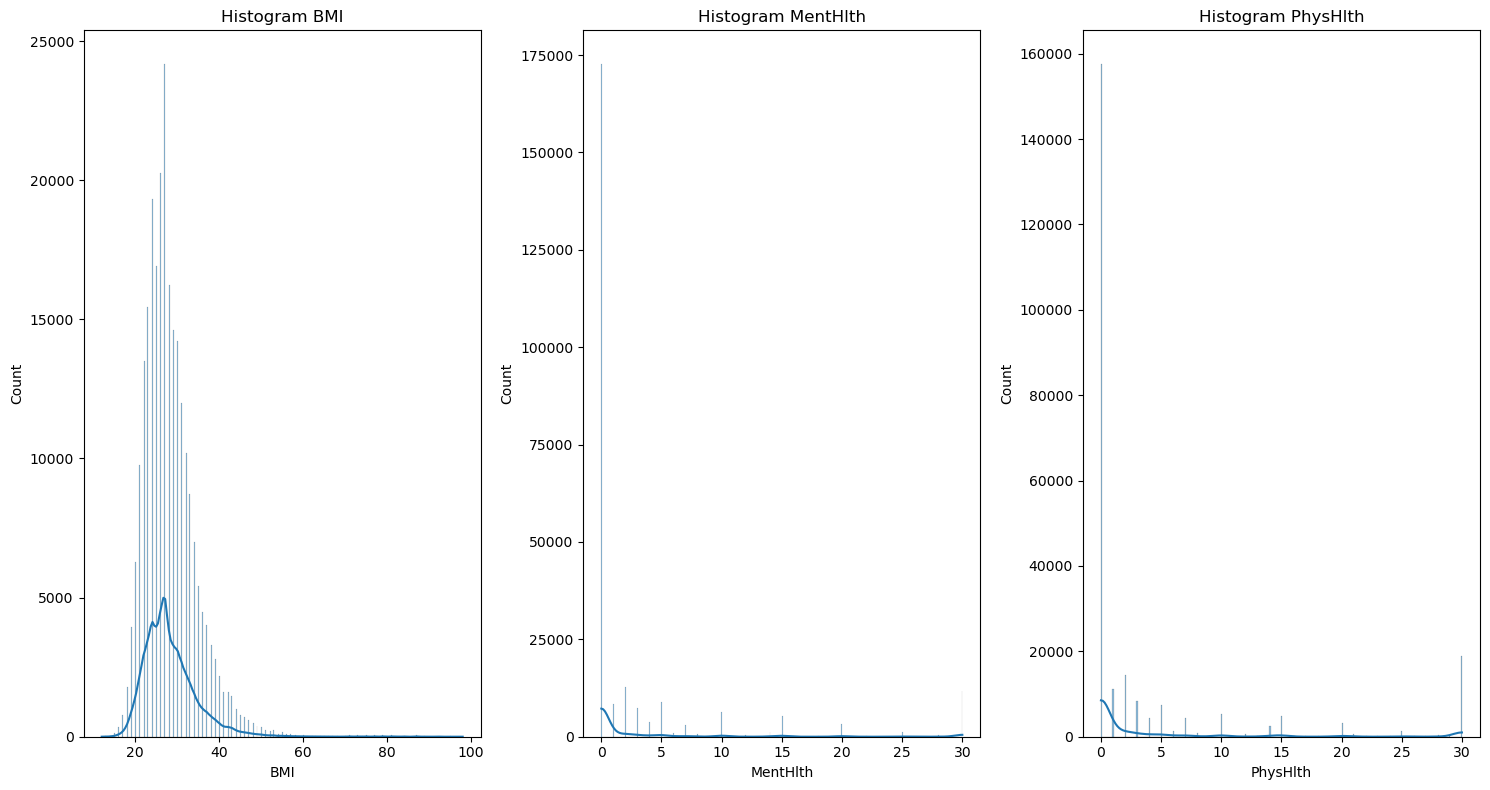

In [17]:
# Cek distribusi dari data numerik
fig, axes = plt.subplots(1, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerik):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram {col}')
    
plt.tight_layout()
plt.show()

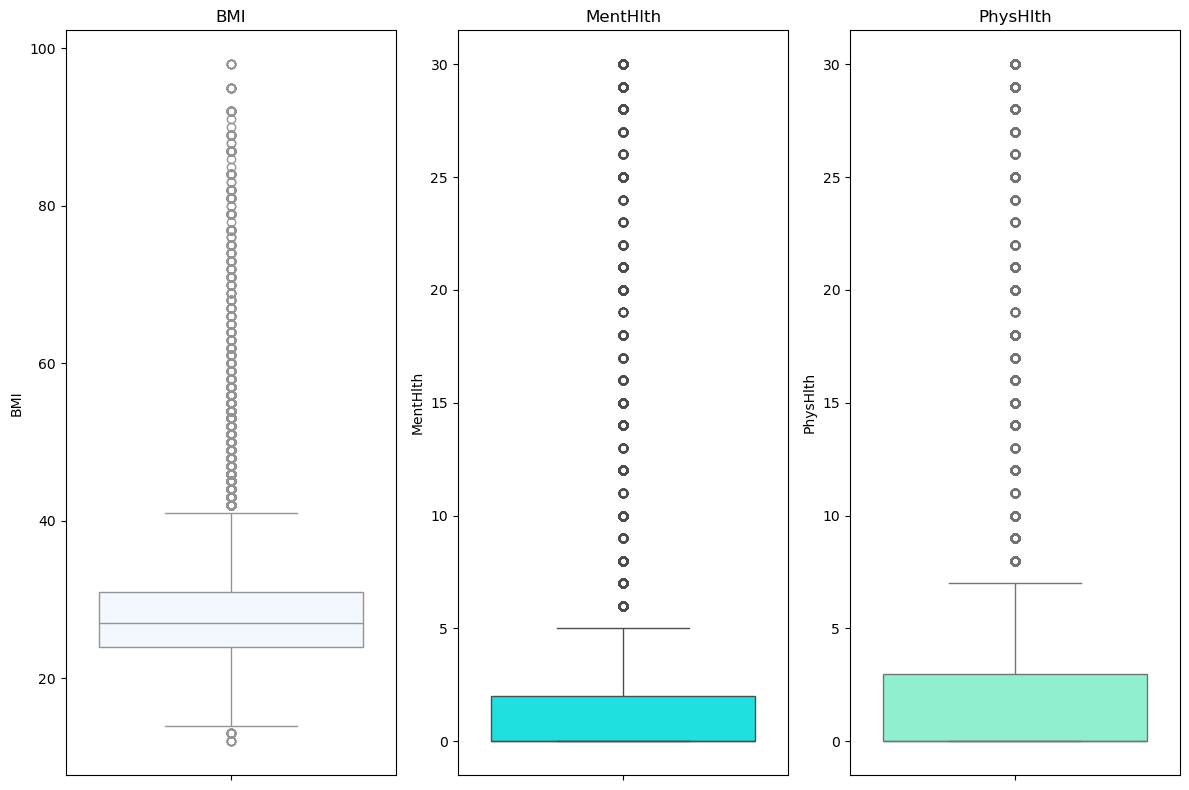

In [18]:
# Cek outlier dari hasil boxplot
fig, ax = plt.subplots(1, 3 , figsize=(12,8))
ax = ax.flatten()

color = ['aliceblue', 'aqua', 'aquamarine']

for i, col in enumerate(numerik):
    sns.boxplot(data=df, y=col, ax=ax[i], color=color[i])
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

### Model Training with Raw Data

In [19]:
# Split Fitur dengan Target
X = df.drop(columns='Diabetes_012')
y = df['Diabetes_012']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Tentukan Semua Kolom Kategori dan Numerik 
cat_col = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthCare', 'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
num_col = numerik

In [23]:
# Train dataset dengan model
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Extra Trees': ExtraTreesClassifier(),
    'KNN': KNeighborsClassifier(),
    'XGB': XGBClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    
    recall = recall_score(y_test, y_pred, pos_label=1)

    
    results[name] = {
            'model': model,
            'recall': recall
        }

    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred))
    print('')

c:\Users\bobe\anaconda3\envs\bootcamp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     42741
           1       0.54      0.15      0.23      7069

    accuracy                           0.86     49810
   macro avg       0.71      0.56      0.58     49810
weighted avg       0.83      0.86      0.83     49810



=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.89      0.88      0.88     42741
           1       0.31      0.33      0.32      7069

    accuracy                           0.80     49810
   macro avg       0.60      0.61      0.60     49810
weighted avg       0.81      0.80      0.80     49810



=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.97      0.92     42741
           1       0.51      0.19      0.28      7069

    accuracy                           0.86     49810
   macro avg       0.69      0.58      0.60     498

In [24]:
# Simpan model terbaik berdasarkan Recall
best_model_name = max(results, key=lambda x: results[x]['recall'])
best_model = results[best_model_name]['model']
best_recall = results[best_model_name]['recall']

print(f'Best model based on recall: {best_model_name}')
print(f'Recall: {best_recall:.4f}')


Best model based on recall: Decision Tree
Recall: 0.3340


In [27]:
# Tampilkan recall setiap model dan di sortir dari recall terbaik ke terburuk
results_df = pd.DataFrame([
    {'Model': name, 'Recall': info['recall']}
    for name, info in results.items()
]).sort_values(by='Recall', ascending=False).reset_index().drop(columns='index')

results_df


,Model,Recall
0,Decision Tree,0.333993
1,KNN,0.215023
2,Extra Trees,0.202150
3,XGB,0.198614
4,Random Forest,0.192955
5,Gradient Boosting,0.189843
6,Logistic Regression,0.148536


Dari hasil training raw data, Decision Tree memiliki recall terbaik sedangkan SVM memiliki hasil terburuk. Hal ini karena SVM sangat menghafal data train yang diberikan sehingga tidak dapat melakukan generalisasi terhadap data test.

### Feature Engineering

Pada tahap ini akan dilakukan pembuatan fitur baru dan/atau mereduksi fitur, karena terdapat banyak fitur yang tidak memiliki korelasi yang cukup besar dengan target. Sebelum itu, mari kita lakukan feature importance untuk mengetahui fitur mana yang paling mempengaruhi menggunakan model dengan recall terbaik.
&nbsp;

Feature engineering pertama yang dapat dilakukan adalah melakukan penambahan fitur dari data yang sudah ada. Berikut merupakan beberapa fitur yang dapat ditambahkan:
```
1. CardioRisk = HighBP + HighChol + HeartDiseaseorAttack + Stroke
2. HealthyLifestyle = PhysActivity + Fruits + Veggies 
3. UnhealthyHabits = Smoker + HvyAlcoholConsump
4. Age_HighBP = Age * HighBP
```
&nbsp;

Penjelasan tambahan fitur

### Next Step
1. Feature Importance (Penting)
2. Remove MentHlth PhysHlth
3. SMOTE or Stacking